# Chapter 12: Cross-Validation and Model Evaluation Techniques

Reproduksi dan pembahasan buku John Sukup, *scikit-learn Cookbook*, Third Edition (Packt, 2025). Kode diadaptasi dari [repo penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_12) beserta exercise solutions. Adaptasi metodologi dijelaskan pada bagian terkait. Dataset sintetis/bawaan dan output di bawah dipakai untuk memahami workflow pembelajaran mesin.

## Daftar Isi

- [Introduction to Cross-Validation](#introduction-to-cross-validation)
- [Advanced Cross-Validation Methods](#advanced-cross-validation-methods)
- [Implementing Cross-Validation in scikit-learn](#implementing-cross-validation-in-scikit-learn)
- [Model Selection Techniques](#model-selection-techniques)
- [Evaluating Model Generalizability](#evaluating-model-generalizability)
- [Practical Exercises in Cross-Validation and Evaluation](#practical-exercises-in-cross-validation-and-evaluation)
- [Pemeriksaan Hasil](#pemeriksaan-hasil)
- [Ringkasan Bab](#ringkasan-bab)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
np.random.seed(2024)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
plt.rcParams.update({'figure.dpi': 100, 'savefig.bbox': 'tight'})
chapter_results = {}

## Introduction to Cross-Validation

K-fold membagi data menjadi K bagian: setiap bagian menjadi validation sekali dan sisanya training. Rata-rata skor mengurangi ketergantungan pada satu split, tetapi fold saling berbagi data training sehingga simpangan baku fold bukan confidence interval independen. StratifiedKFold menjaga proporsi kelas; tidak memperbaiki dependensi waktu atau identitas sampel.

KFold dan StratifiedKFold dibandingkan pada 500 sampel sintetis. Scaling ditempatkan di pipeline dan di-fit ulang pada tiap fold. Fit preprocessing pada seluruh data sebelum CV menyebabkan leakage. CV mengevaluasi workflow model, bukan menggantikan target atau pertanyaan penelitian yang jelas.

In [2]:
# Load the libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load the dataset
X, y = make_classification(n_samples=500, n_features=10, n_informative=8,
                           n_redundant=2, n_classes=2, random_state=2024)

In [3]:
# Initialize the k-fold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=2024)

# Iterate through the folds and evaluate
accuracies = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=2024))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))
print(f"Average accuracy (KFold): {np.mean(accuracies):.3f}")

# Use stratified k-fold for balanced class splits
strat_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)
strat_accuracies = []
for train_index, test_index in strat_kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=2024))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    strat_accuracies.append(accuracy_score(y_test, y_pred))
print(f"Average accuracy (StratifiedKFold): {np.mean(strat_accuracies):.3f}")

chapter_results['kfold_accuracy'] = float(np.mean(accuracies))
chapter_results['stratified_accuracy'] = float(np.mean(strat_accuracies))

Average accuracy (KFold): 0.758
Average accuracy (StratifiedKFold): 0.766


## Advanced Cross-Validation Methods

Leave-One-Out melatih n model dengan satu sampel validation masing-masing; biaya tinggi dan variasi skor dapat besar. Diabetes memuat 442 sampel dengan target kontinu. MSE adalah rata-rata kuadrat error dalam satuan target kuadrat; scoring neg_mean_squared_error dikembalikan negatif karena scikit-learn memaksimalkan skor, sehingga tanda dibalik untuk melaporkan MSE.

Nested CV memisahkan inner fold untuk tuning dan outer fold untuk estimasi generalisasi seluruh proses pencarian. Contoh Ridge memakai pencarian alpha di inner CV, dengan outer R² yang dinyatakan eksplisit. GroupKFold diperlukan ketika orang/perangkat yang sama muncul berulang; TimeSeriesSplit menjaga training mendahului validation. Random fold dapat bocor pada waktu. Contoh tambahan memperlihatkan pemisahan group dan urutan waktu, tanpa menyamakan dataset Diabetes dengan time series.

In [4]:
# Load the libraries
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge

# Load the dataset
data = load_diabetes()
X = data.data
y = data.target

In [5]:
# Apply Leave-One-Out cross-validation with MSE scoring
loo = LeaveOneOut()
model = Ridge(alpha=1.0)
scores = cross_val_score(model, X, y, cv=loo, scoring="neg_mean_squared_error")
print(f"LOOCV mean MSE: {-np.mean(scores):.3f}")

# Define a grid for hyperparameter tuning
param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

# Apply nested cross-validation using GridSearchCV (default scoring is fine for outer CV)
nested_scores = cross_val_score(
    GridSearchCV(Ridge(), param_grid, cv=5, scoring="r2"), X, y, cv=5, scoring="r2"
)
print(f"Nested CV mean R²: {np.mean(nested_scores):.3f}")

chapter_results['diabetes_loocv_mse'] = float(-np.mean(scores))
chapter_results['diabetes_nested_r2'] = float(np.mean(nested_scores))

LOOCV mean MSE: 3327.655


Nested CV mean R²: 0.480


## Implementing Cross-Validation in scikit-learn

cross_val_score mengembalikan satu metrik per fold; cross_validate dapat mengembalikan banyak metrik dan waktu fit/score. GridSearchCV mencari parameter melalui CV lalu refit pada seluruh input training. best_score_ adalah skor terbaik pencarian internal dan cenderung optimistis setelah banyak pilihan, bukan test independen.

Contoh kelas 70/30 melaporkan accuracy, precision, recall, dan F1 untuk positive class 1. Pipeline scaling berada di setiap fold. Skor CV dan holdout menjawab desain evaluasi berbeda, sehingga tidak dibandingkan sebagai angka yang pasti identik.

In [6]:
# Load the libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_validate, GridSearchCV

# Load and prepare the dataset
X, y = make_classification(n_samples=500, n_features=10, weights=[0.7, 0.3], random_state=2024)

In [7]:
# Use cross_val_score() to compute average accuracy
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=2024))
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Mean accuracy: {np.mean(scores):.3f}")

# Use cross_validate() to compute multiple metrics
results = cross_validate(model, X, y, cv=5,
                         scoring=['accuracy', 'precision', 'recall', 'f1'])
print(f"Mean precision: {np.mean(results['test_precision']):.3f}")
print(f"Mean recall: {np.mean(results['test_recall']):.3f}")
print(f"Mean F1: {np.mean(results['test_f1']):.3f}")

# Use GridSearchCV() for hyperparameter tuning with cross-validation
param_grid = {"logisticregression__C": [0.01, 0.1, 1, 10]}
grid = GridSearchCV(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=2024)), param_grid, cv=5, scoring='accuracy')
grid.fit(X, y)
print(f"Best hyperparameter (C): {grid.best_params_['logisticregression__C']}")
print(f"Best accuracy: {grid.best_score_:.3f}")

Mean accuracy: 0.908


Mean precision: 0.874
Mean recall: 0.813
Mean F1: 0.841


Best hyperparameter (C): 0.1
Best accuracy: 0.918


## Model Selection Techniques

Grid search mencoba semua kombinasi pada grid; randomized search mengambil sampel distribusi parameter dengan budget tetap. Distribusi loguniform cocok untuk C yang mencakup beberapa orde magnitudo. Pemilihan metric harus mencerminkan biaya kesalahan, bukan hanya accuracy pada kelas tidak seimbang.

Data dibagi training/test secara stratified sebelum pencarian. Kedua metode memakai CV training; model randomized search dievaluasi satu kali pada test sesuai workflow contoh. Test tidak dipakai memilih C. Nested CV diperlukan bila ingin mengestimasi keseluruhan strategi perbandingan/pencarian dengan lebih independen.

In [8]:
# Load the libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score

# Load and split the dataset
X, y = make_classification(n_samples=500, n_features=10, weights=[0.7, 0.3], random_state=2024)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=2024)

In [9]:
# Use GridSearchCV to evaluate all combinations in the parameter grid
param_grid = {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=2024)), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print(f"GridSearchCV best C: {grid.best_params_['logisticregression__C']}")

# Use RandomizedSearchCV to evaluate a random sample of parameters
from scipy.stats import loguniform
param_dist = {"logisticregression__C": loguniform(1e-3, 1e2)}
random_search = RandomizedSearchCV(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=2024)), param_distributions=param_dist,
                                    n_iter=10, cv=5, scoring='accuracy', random_state=2024)
random_search.fit(X_train, y_train)
print(f"RandomizedSearchCV best C: {random_search.best_params_['logisticregression__C']:.4f}")

# Evaluate final model performance
final_model = random_search.best_estimator_
y_pred = final_model.predict(X_test)
print(f"Final accuracy on test set: {accuracy_score(y_test, y_pred):.3f}")

chapter_results['randomized_best_C'] = float(random_search.best_params_['logisticregression__C'])
chapter_results['randomized_test_accuracy'] = accuracy_score(y_test, y_pred)

GridSearchCV best C: 1


RandomizedSearchCV best C: 0.8711
Final accuracy on test set: 0.913


## Evaluating Model Generalizability

Learning curve memperlihatkan skor training dan validation ketika jumlah training bertambah. Gap besar dapat mengindikasikan variance tinggi; kedua skor rendah dapat mengindikasikan bias, fitur lemah, atau label sulit. Validation curve memvariasikan hyperparameter seperti C: C kecil berarti regularisasi lebih kuat. Bentuk kurva merupakan diagnosis, bukan bukti tunggal penyebab kesalahan.

Kurva dihitung melalui CV dengan preprocessing di pipeline. Shuffle dan seed ditetapkan untuk learning curve. Memeriksa kurva pada seluruh dataset adalah analisis eksploratif; data yang sama tidak kemudian disebut test independen setelah dipakai membuat pilihan model.

In [10]:
# Load the libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, validation_curve

# Load the dataset
X, y = make_classification(n_samples=1000, n_features=20, weights=[0.7, 0.3], random_state=2024)

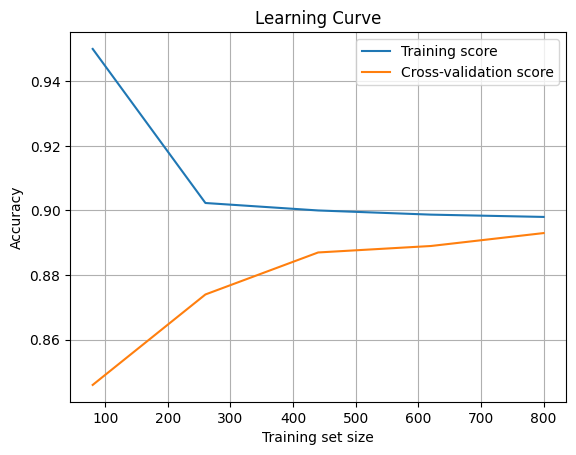

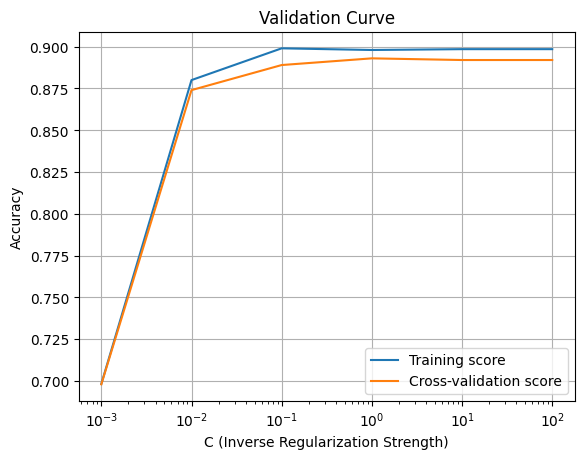

In [11]:
# Plot a learning curve
train_sizes, train_scores, test_scores = learning_curve(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=2024)), X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=2024)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, test_mean, label='Cross-validation score')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

# Plot a validation curve
param_range = np.logspace(-3, 2, 6)
train_scores, test_scores = validation_curve(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=2024)), X, y, param_name="logisticregression__C", param_range=param_range,
    cv=5, scoring='accuracy')

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.semilogx(param_range, train_mean, label='Training score')
plt.semilogx(param_range, test_mean, label='Cross-validation score')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Accuracy')
plt.title('Validation Curve')
plt.legend()
plt.grid(True)
plt.show()

## Practical Exercises in Cross-Validation and Evaluation

Exercise 1 mengumpulkan accuracy, precision, recall, dan F1 logistic regression pada lima fold. Exercise 2 melakukan grid search pipeline scaler–SVC hanya pada training lalu membuat report holdout. Exercise 3 memakai data training latihan 2 untuk kurva learning/validation logistic regression; holdout latihan 2 tidak dipakai menggambar kurva. Setiap metric diberi konteks kelas dan splitnya.

In [12]:
# Load libraries
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

# Load the dataset
X, y = make_classification(n_samples=500, n_features=10, random_state=2024)

# Cross-validate and collect metrics
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=2024))
results = cross_validate(model, X, y, cv=5, scoring=["accuracy", "precision", "recall", "f1"])

for metric in ["test_accuracy", "test_precision", "test_recall", "test_f1"]:
    print(f"{metric}: {results[metric].mean():.3f}")

chapter_results['exercise_cv_metrics'] = {metric:float(results[metric].mean()) for metric in ['test_accuracy','test_precision','test_recall','test_f1']}

test_accuracy: 0.898
test_precision: 0.900
test_recall: 0.895
test_f1: 0.897


In [13]:
# Load libraries
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Load and split the dataset
X, y = make_classification(n_samples=500, n_features=10, random_state=2024)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=2024)

# Perform grid search
param_grid = {"svc__C": [0.1, 1, 10], "svc__kernel": ["linear", "rbf"]}
grid = GridSearchCV(make_pipeline(StandardScaler(), SVC()), param_grid, cv=5)
grid.fit(X_train, y_train)
print(f"Best parameters: {grid.best_params_}")

# Evaluate on the test set
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

chapter_results['exercise_svc_test_accuracy'] = accuracy_score(y_test, y_pred)

Best parameters: {'svc__C': 0.1, 'svc__kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.92      0.89      0.91        76
           1       0.89      0.92      0.91        74

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150



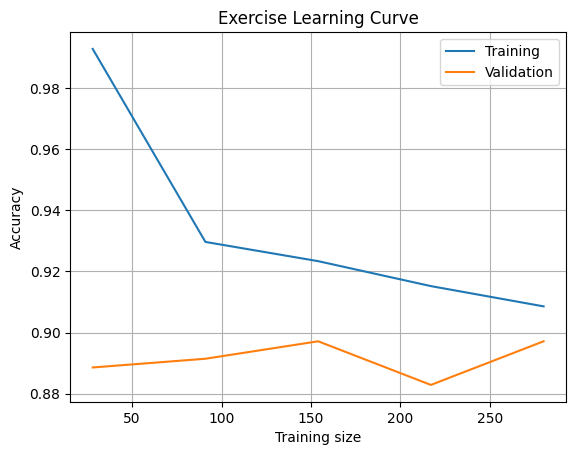

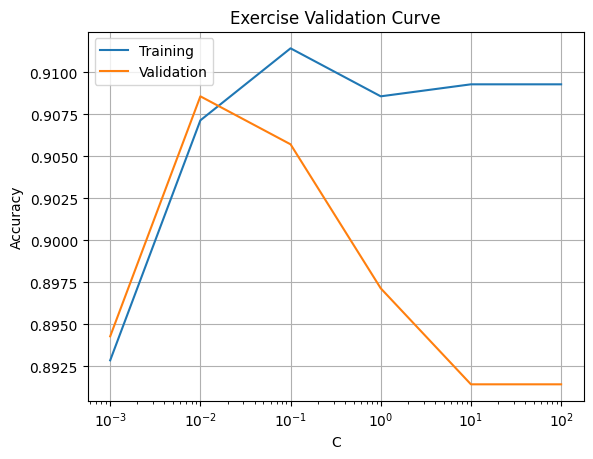

In [14]:
from sklearn.model_selection import learning_curve, validation_curve
curve_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=2024))
train_sizes, train_scores, test_scores = learning_curve(
    curve_model, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=2024)
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation')
plt.xlabel('Training size'); plt.ylabel('Accuracy'); plt.title('Exercise Learning Curve')
plt.legend(); plt.grid(True); plt.show()
param_range = np.logspace(-3, 2, 6)
train_scores, test_scores = validation_curve(
    curve_model, X_train, y_train, param_name='logisticregression__C',
    param_range=param_range, cv=5, scoring='accuracy')
plt.semilogx(param_range, train_scores.mean(axis=1), label='Training')
plt.semilogx(param_range, test_scores.mean(axis=1), label='Validation')
plt.xlabel('C'); plt.ylabel('Accuracy'); plt.title('Exercise Validation Curve')
plt.legend(); plt.grid(True); plt.show()
chapter_results['exercise_curve_training_samples'] = len(X_train)

### Pemeriksaan Tambahan

Split group dan time series diuji agar identitas dan urutan tidak bocor antarbagian.

In [15]:
from sklearn.model_selection import GroupKFold, TimeSeriesSplit
groups = np.repeat(np.arange(12), 3)
group_X = np.arange(len(groups)).reshape(-1, 1)
for training, validation in GroupKFold(n_splits=3).split(group_X, groups=groups):
    assert not set(groups[training]) & set(groups[validation])
time_splits = []
for training, validation in TimeSeriesSplit(n_splits=3).split(group_X):
    assert training.max() < validation.min()
    time_splits.append({'training_end':int(training.max()), 'validation_start':int(validation.min())})
chapter_results['group_disjoint_folds'] = 3
chapter_results['time_ordered_folds'] = time_splits
display(pd.DataFrame(time_splits))

,training_end,validation_start
0,8,9
1,17,18
2,26,27


## Pemeriksaan Hasil

Assertion di bawah memeriksa konsistensi hasil dan keluaran, bukan membuktikan seluruh asumsi statistik.

In [16]:
assert chapter_results
assert chapter_results['diabetes_loocv_mse'] >= 0
assert chapter_results['group_disjoint_folds'] == 3
assert 0 <= chapter_results['exercise_svc_test_accuracy'] <= 1
print(json.dumps(chapter_results, indent=2))

{
  "kfold_accuracy": 0.758,
  "stratified_accuracy": 0.766,
  "diabetes_loocv_mse": 3327.6551045592246,
  "diabetes_nested_r2": 0.4801969563236912,
  "randomized_best_C": 0.8711091880089797,
  "randomized_test_accuracy": 0.9133333333333333,
  "exercise_cv_metrics": {
    "test_accuracy": 0.898,
    "test_precision": 0.89950512214342,
    "test_recall": 0.8949387755102041,
    "test_f1": 0.8965727494881447
  },
  "exercise_svc_test_accuracy": 0.9066666666666666,
  "exercise_curve_training_samples": 350,
  "group_disjoint_folds": 3,
  "time_ordered_folds": [
    {
      "training_end": 8,
      "validation_start": 9
    },
    {
      "training_end": 17,
      "validation_start": 18
    },
    {
      "training_end": 26,
      "validation_start": 27
    }
  ]
}


## Ringkasan Bab

KFold dan StratifiedKFold menghasilkan rata-rata accuracy **0.758** dan **0.766** pada dataset contoh. Diabetes menghasilkan LOOCV MSE **3327.66** dan nested-CV R² **0.480**; metrik tersebut berbeda satuan dan tidak dibandingkan langsung.

Randomized search menghasilkan holdout accuracy **0.913**, sedangkan latihan scaler–SVC mencapai **0.907** pada dataset/split latihan. Kurva latihan memakai 350 sampel training dan tidak menyentuh holdout. Pemeriksaan group/time memastikan identitas tidak menyeberang fold dan validation selalu mengikuti training. Evaluasi harus mengikuti cara model akan menerima data baru.